In [393]:
from math import floor

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import scipy.io as sio
from scipy.fftpack import fft, ifft
from rich import print
# Hann window

In [394]:
def read_osc(filename):  
    """
    Reads a csv file with oscilloscope data and returns a dataframe with the data and a dictionary with the parameters.
    filename: Scope csv file name
    """
    df = pd.read_csv(filename, names=['name','value','c2','t','v','c5'])
    data = df.loc[:17, ['name', 'value']].set_index('name')
    df = df[['t', 'v']]
    data.drop(data.index[3:5], inplace=True)
    params = {k: v['value'] for k, v in data.to_dict('index').items()}
    df['t'] *= 1000
    params['tit'] = f"CANAL: {params['Source']}"
    params['xl'] = 'tiempo[ms]'
    params['yl'] = f"Amplitud[{params['Vertical Units']}]"
    return df, params


---
Fourier transform for spectral analyses
---


In [395]:
## Generate a multispectral noisy signal

# simulation parameters
srate = 1234  # in Hz
npnts = srate * 2  # 2 seconds: "time points"
time = np.arange(0, npnts) / srate  # "time vector" = [0, 1/srate, ... 2 - 1/srate] ("normalized time points")

print(f"Sampling rate: {srate} Hz\nNumber of points: {npnts}\nTime: [0, {time[1]}, ..., {time[-1]} = 2-1/srate]")

Sampling rate: 1234 Hz
Number of points: 2468
Time: [0, 0.0008103727714748784, ..., 1.9991896272285252 = 2-1/srate]

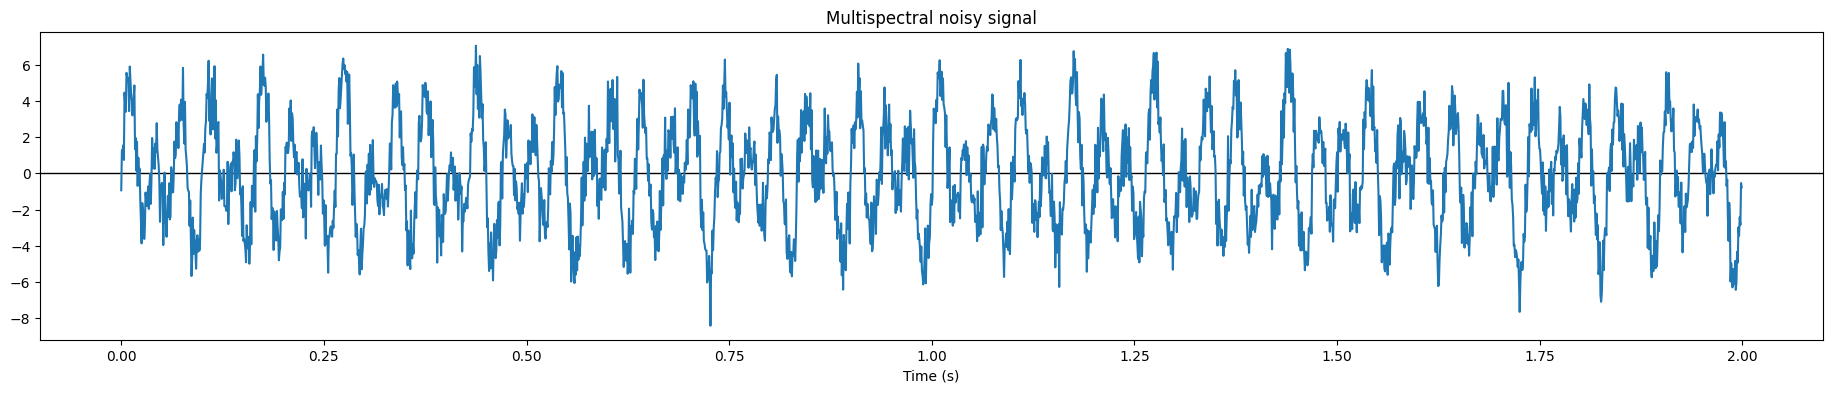

In [396]:
# frequencies to include
frex = [12, 19, 30]

signal = np.zeros(npnts)

# loop over frequencies to create signal
A = [1, 2, 3]  # amplitudes of the different frequencies
for i in range(0, len(frex)):
    signal = signal + A[i] * np.sin(2 * np.pi * frex[i] * time)  # fi + 1 = [1, 2, 3]

# add some noise
signal = signal + np.random.randn(npnts)  # add some noise

plt.figure(figsize=(23, 4))
plt.axhline(0, color='black', lw=1)
plt.title('Multispectral noisy signal')
plt.xlabel('Time (s)')  # time vector is the normalized time points 
plt.plot(time, signal)
plt.show()  # plot the signal versus the time vector

f Nyquist : 617.0

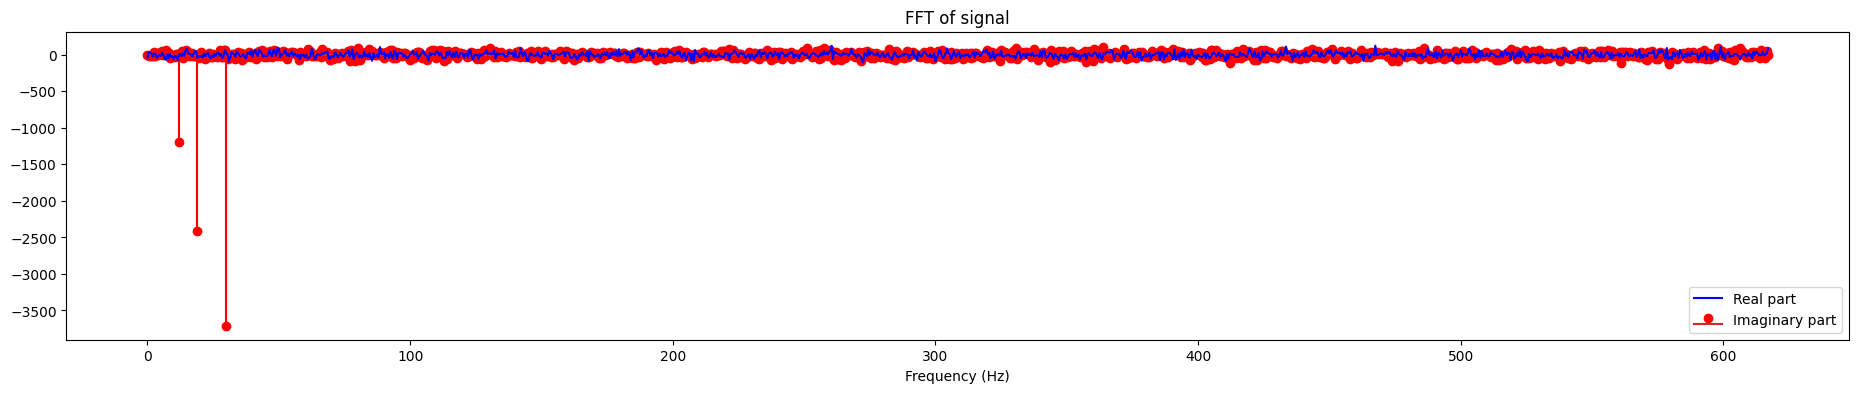

In [397]:
# amplitude spectrum via Fourier transform
signalX = fft(signal)
signalAmp = 2 * np.abs(signalX) / npnts  # amplitude spectrum (scaled by npnts/2)

# vector of frequencies in Hz
hz = np.linspace(0, srate / 2, int(np.floor(npnts / 2) + 1))  # 1234 / 2 = 617 Hz
print(f"f Nyquist : {hz[-1]}")

# plot the signalX amplitude spectrum
plt.figure(figsize=(23, 4))
plt.stem(hz, signalX[0:int(np.floor(npnts / 2) + 1)].imag, 'r', label='Imaginary part')
plt.plot(hz, signalX[0:int(np.floor(npnts / 2) + 1)].real, 'b', label='Real part')
# plt.xlim([0, 60])
plt.xlabel('Frequency (Hz)')
plt.title('FFT of signal')
plt.legend()
plt.show()

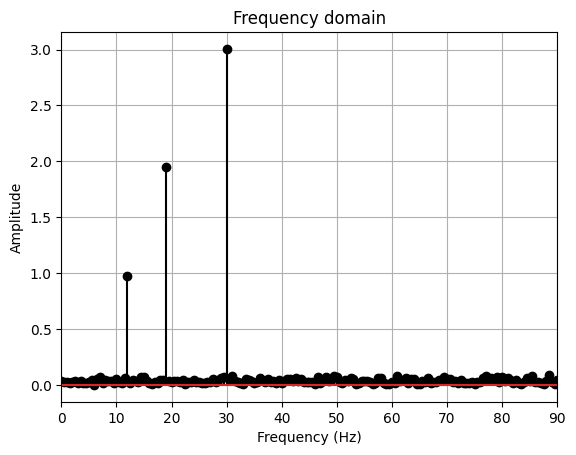

In [398]:
# plot the amplitude spectrum
plt.stem(hz, signalAmp[0: len(hz)], "k")
plt.xlim([0, np.max(frex) * 3])
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.grid()
plt.title("Frequency domain")
plt.show()

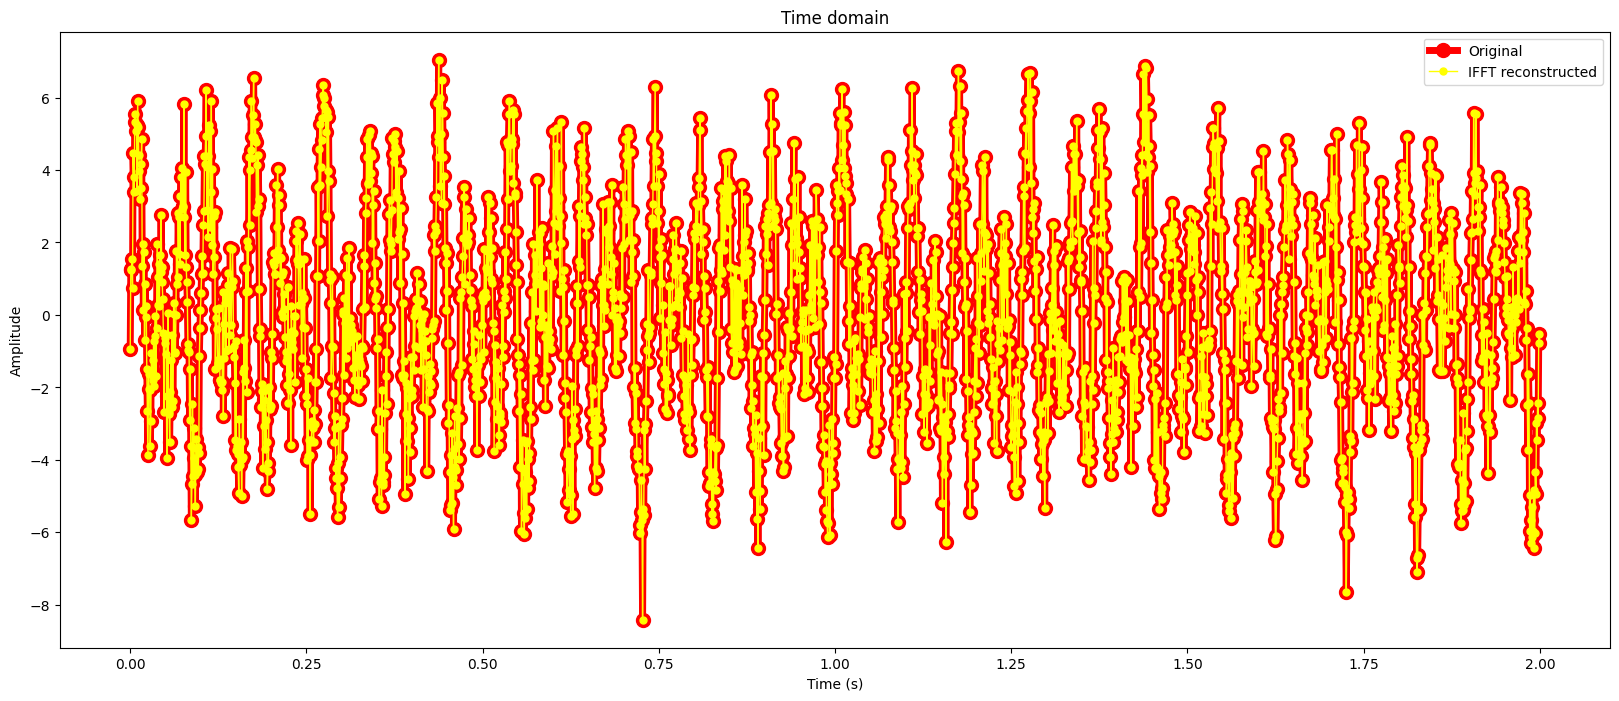

In [399]:
## plot the original signal and the reconstructed signal
ifft_real = np.real(ifft(signalX))

plt.figure(figsize=(20, 8))
plt.plot(time, signal, "ro-", label="Original", linewidth=5, markersize=10)
plt.plot(time, ifft_real,
    "-o",
    label="IFFT reconstructed",
    linewidth=1,
    markersize=5,
    alpha=1,
    color="yellow",
)

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Time domain")
plt.legend()
plt.show()

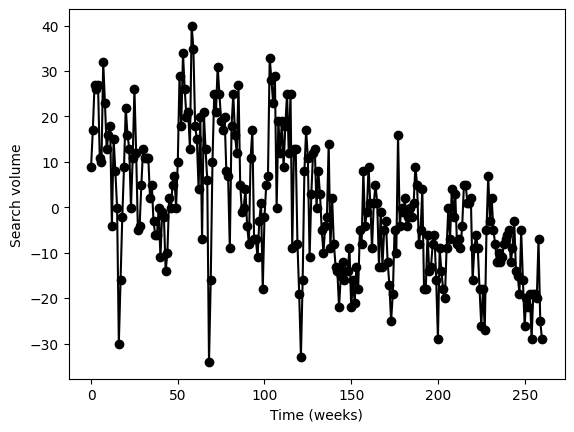

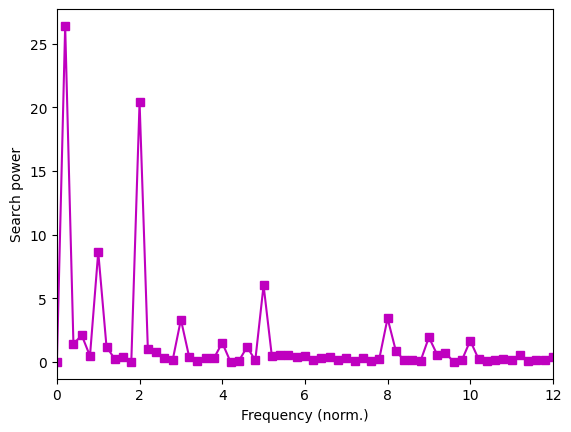

In [400]:
## example with real data

# data downloaded from https://trends.google.com/trends/explore?date=today%205-y&geo=US&q=signal%20processing
osc_data = [69, 77, 87, 86, 87, 71, 70, 92, 83, 73, 76, 78, 56, 75, 68, 60, 30, 44, 58, 69, 82, 76, 73, 60, 71, 86,
              72, 55, 56, 65, 73, 71, 71, 71, 62, 65, 57, 54, 54, 60, 49, 59, 58, 46, 50, 62, 60, 65, 67, 60, 70, 89,
              78, 94, 86, 80, 81, 73, 100, 95, 78, 75, 64, 80, 53, 81, 73, 66, 26, 44, 70, 85, 81, 91, 85, 79, 77, 80,
              68, 67, 51, 78, 85, 76, 72, 87, 65, 59, 60, 64, 56, 52, 71, 77, 53, 53, 49, 57, 61, 42, 58, 65, 67, 93,
              88, 83, 89, 60, 79, 72, 79, 69, 78, 85, 72, 85, 51, 73, 73, 52, 41, 27, 44, 68, 77, 71, 49, 63, 72, 73,
              60, 68, 63, 55, 50, 56, 58, 74, 51, 62, 52, 47, 46, 38, 45, 48, 44, 46, 46, 51, 38, 44, 39, 47, 42, 55,
              52, 68, 56, 59, 69, 61, 51, 61, 65, 61, 47, 59, 47, 55, 57, 48, 43, 35, 41, 55, 50, 76, 56, 60, 59, 62,
              56, 58, 60, 58, 61, 69, 65, 52, 55, 64, 42, 42, 54, 46, 47, 52, 54, 44, 31, 51, 46, 42, 40, 51, 60, 53,
              64, 58, 63, 52, 53, 51, 56, 65, 65, 61, 61, 62, 44, 51, 54, 51, 42, 34, 42, 33, 55, 67, 57, 62, 55, 52,
              48, 50, 48, 49, 52, 53, 54, 55, 48, 51, 57, 46, 45, 41, 55, 44, 34, 40, 38, 41, 31, 41, 41, 40, 53, 35,
              31]
N = len(osc_data)

# possible normalizations...
osc_data = osc_data - np.mean(osc_data) # type: ignore

# power
searchpow = np.abs(fft(osc_data) / N) ** 2
hz = np.linspace(0, 52, N)

plt.plot(osc_data, 'ko-')
plt.xlabel('Time (weeks)')
plt.ylabel('Search volume')
plt.show()

plt.plot(hz, searchpow, 'ms-')
plt.xlabel('Frequency (norm.)')
plt.ylabel('Search power')
plt.xlim([0, 12])
plt.show()

In [401]:
osc_raw = read_osc("F0000CH1.CSV")
osc_meta = osc_raw[1]
print(osc_meta)

sample_interval = pd.to_numeric(osc_meta["Sample Interval"])
srate = 1/sample_interval
print(f"{sample_interval=}, {srate=}")

osc_data = list(osc_raw[0]["v"][400:400+833])
npnts = len(osc_data)
print(f"{npnts=}")
print(osc_data[:10])

time = np.arange(0, len(osc_data))/srate
print(f"{time[-1]=}")

{
    'Record Length': '2.500000e+03',
    'Sample Interval': '4.000000e-04',
    'Trigger Point': '0.000000000000e+00',
    'Source': 'CH1',
    'Vertical Units': 'V',
    'Vertical Scale': '2.000000e+00',
    'Vertical Offset': '0.000000e+00',
    'Horizontal Units': 's',
    'Horizontal Scale': '1.000000e-01',
    'Pt Fmt': 'Y',
    'Yzero': '0.000000e+00',
    'Probe Atten': '1.000000e+00',
    'Model Number': 'TBS1062',
    'Serial Number': 'C010479',
    'Firmware Version': 'FV:v26.01',
    'tit': 'CANAL: CH1',
    'xl': 'tiempo[ms]',
    'yl': 'Amplitud[V]'
}

sample_interval=np.float64(0.0004), srate=np.float64(2500.0)

npnts=833

[2.72, 2.56, 2.32, 2.08, 1.92, 1.76, 1.52, 1.36, 1.2, 0.96]

time[-1]=np.float64(0.3328)

Text(0.5, 1.0, 'Signal vs Time')

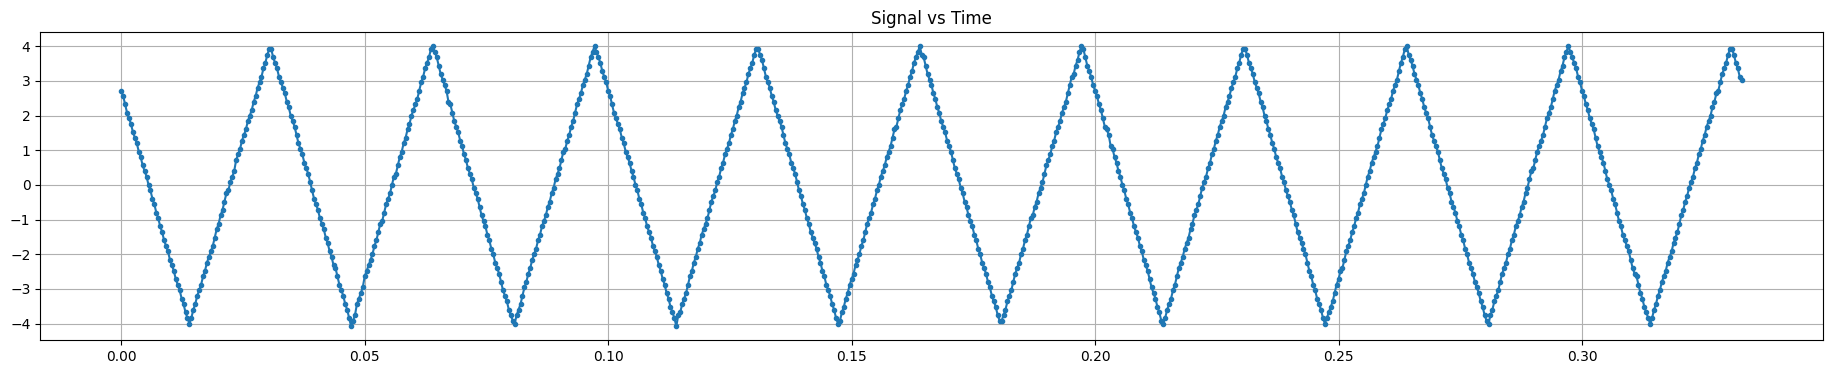

In [402]:
plt.figure(figsize=(23, 4))
plt.plot(time, osc_data, '.-')
plt.grid()
plt.title("Signal vs Time")

f Nyquist : 1250.0, 417 pts

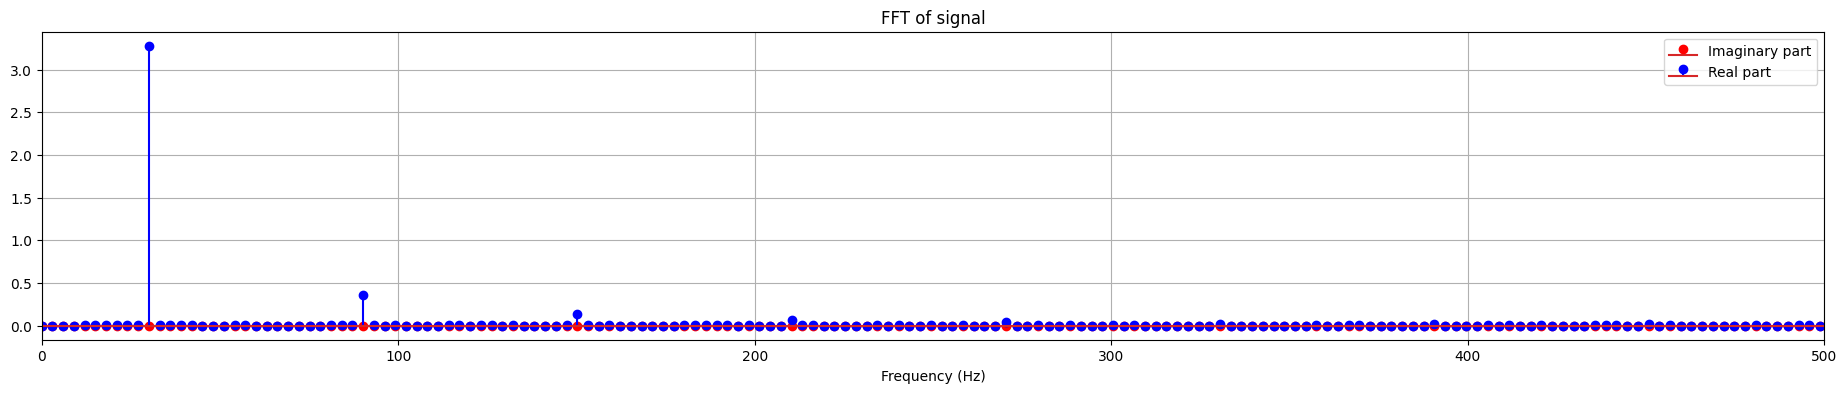

In [412]:
osc_fft = np.abs(fft(osc_data)) / (npnts/2)

# vector of frequencies in Hz
hz = np.linspace(0, srate / 2, int(np.floor(npnts / 2) + 1))  
print(f"f Nyquist : {hz[-1]}, {len(hz)} pts")

# plot the osc amplitude spectrum
plt.figure(figsize=(23, 4))
plt.stem(hz, osc_fft[0:int(np.floor(npnts / 2) + 1)].imag, 'r', label='Imaginary part')
plt.stem(hz, osc_fft[0:int(np.floor(npnts / 2) + 1)].real, 'b', label='Real part')
plt.xlim([0, 500])
plt.xlabel('Frequency (Hz)')
plt.title('FFT of signal')
plt.grid()
plt.legend()
plt.show()

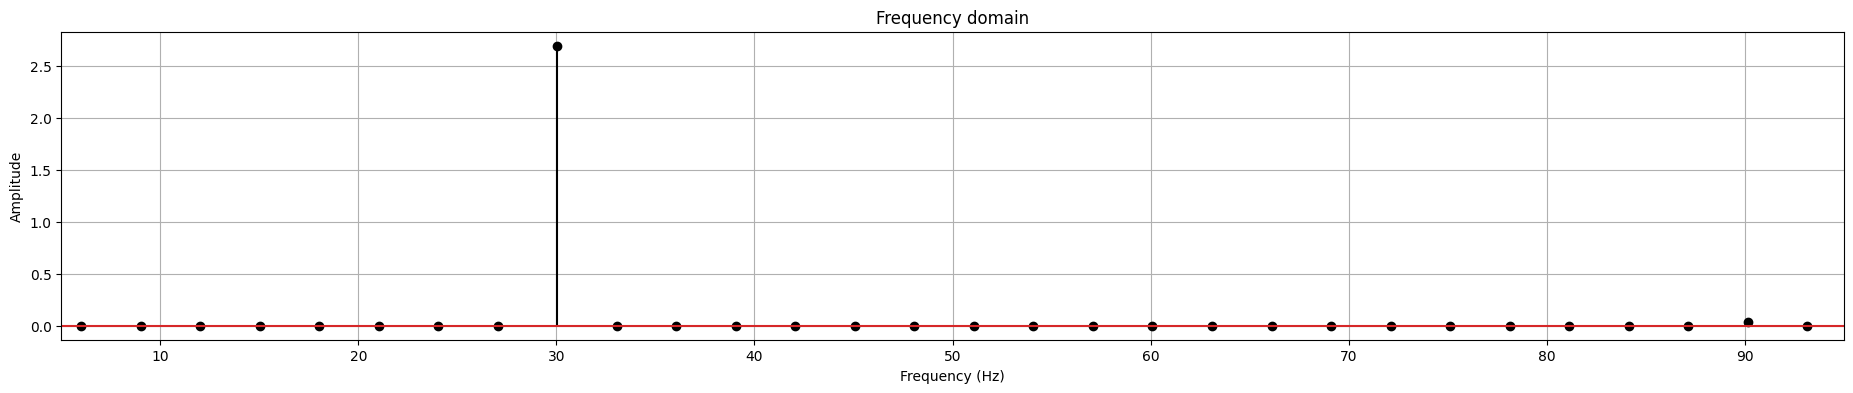

In [409]:
# plot the POWER spectrum
N = len(osc_data)
osc_pow = np.abs(fft(osc_data) / N) ** 2

plt.figure(figsize=(23, 4))
plt.stem(hz, osc_pow[0: len(hz)], "k")
plt.xlim([5, 95])
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.grid()
plt.title("Frequency domain")
plt.show()